In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl


In [25]:
"""
Características de entrada en orden:
1) CRIM: tasa de criminalidad per cápita por ciudad
2) ZN: proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies
cuadrados
3) INDUS: proporción de acres de negocios no minoristas por ciudad
4) CHAS: variable dummy del río Charles (1 si el tramo limita con el río; 0 de lo contrario)
5) NOX: concentración de óxidos de nitrógeno (partes por 10 millones) [parts/10M]
6) RM: número promedio de habitaciones por vivienda
7) AGE: proporción de unidades ocupadas por sus propietarios construidas antes de 1940
8) DIS: distancias ponderadas a cinco centros de empleo de Boston
9) RAD: índice de accesibilidad a las autopistas radiales
10) TAX: tasa de impuesto sobre la propiedad a valor completo por $10,000 [$/10k]
11) PTRATIO: proporción alumno-maestro por ciudad
12) B: El resultado de la ecuación B=1000(Bk - 0.63)^2 donde Bk es la proporción de negros
por ciudad
13) LSTAT: % de población de menor estatus socioeconómico

Variable de salida (target):
14) MEDV: Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares
[k$]
"""

'\nCaracterísticas de entrada en orden:\n1) CRIM: tasa de criminalidad per cápita por ciudad\n2) ZN: proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies\ncuadrados\n3) INDUS: proporción de acres de negocios no minoristas por ciudad\n4) CHAS: variable dummy del río Charles (1 si el tramo limita con el río; 0 de lo contrario)\n5) NOX: concentración de óxidos de nitrógeno (partes por 10 millones) [parts/10M]\n6) RM: número promedio de habitaciones por vivienda\n7) AGE: proporción de unidades ocupadas por sus propietarios construidas antes de 1940\n8) DIS: distancias ponderadas a cinco centros de empleo de Boston\n9) RAD: índice de accesibilidad a las autopistas radiales\n10) TAX: tasa de impuesto sobre la propiedad a valor completo por $10,000 [$/10k]\n11) PTRATIO: proporción alumno-maestro por ciudad\n12) B: El resultado de la ecuación B=1000(Bk - 0.63)^2 donde Bk es la proporción de negros\npor ciudad\n13) LSTAT: % de población de menor estatus socioeconómi

In [6]:
df = pd.read_csv('../data/raw/house-prices-tp.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [11]:
df.CRIM.isnull().sum() # Comprobamos cantidad de valores nulos en la columna CRIM.

np.int64(23)

In [12]:
df[df.CRIM < 0] # Comprobamos que no hay valores negativos.

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV


In [13]:
df.describe() # Comprobamos estadísticos de las columnas numéricas.

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,533.000000,534.000000,541.000000,533.000000,532.000000,535.000000,532.000000,541.000000,528.000000,538.000000,528.000000,534.000000,534.000000,535.000000
mean,5.845517,13.197175,11.218725,0.090056,0.560050,6.291839,67.632303,3.944102,9.699379,409.575089,18.429904,347.806040,13.028092,22.746809
std,13.828631,24.902981,6.942021,0.286531,0.119472,0.782403,28.461925,2.255689,8.684495,167.689379,2.194759,99.636208,7.579972,9.491452
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.084470,0.000000,5.130000,0.000000,0.453000,5.875500,42.275000,2.112100,4.000000,279.000000,17.000000,369.530000,7.150000,16.750000
50%,0.315330,0.000000,9.690000,0.000000,0.538000,6.208000,76.500000,3.340107,5.000000,335.000000,19.000000,390.815000,11.465000,21.200000
75%,4.871410,20.000000,18.100000,0.000000,0.643986,6.638500,93.825000,5.400700,23.632660,666.000000,20.200000,395.890000,17.205000,26.300000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


<Axes: xlabel='CRIM'>

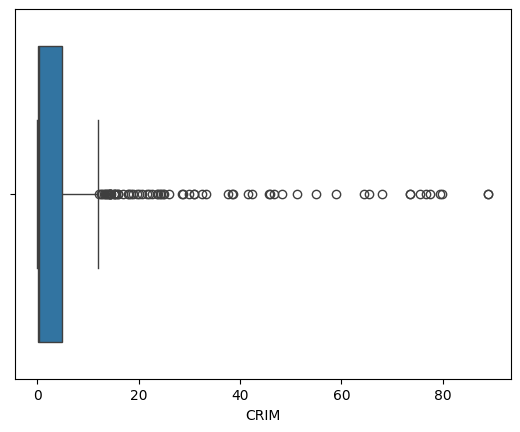

In [15]:
sns.boxplot(x=df.CRIM) # Comprobamos la distribución de la columna CRIM.

In [22]:
df.CRIM[df.CRIM > 1].count() # Comprobamos cantidad de valores mayores a 1 en la columna CRIM.

np.int64(201)

<Axes: xlabel='CRIM', ylabel='Count'>

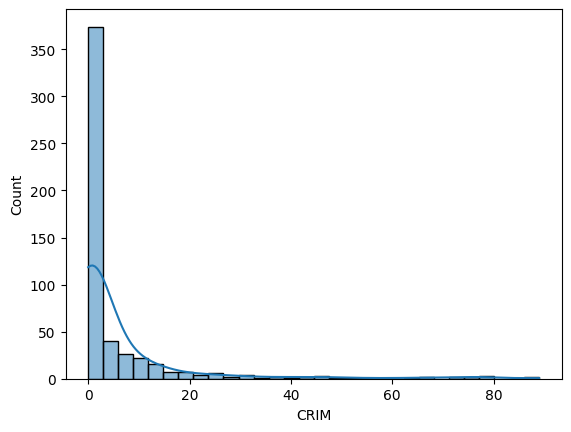

In [20]:
sns.histplot(data=df, x='CRIM', bins=30, kde=True) 